In [ ]:
%matplotlib inline
import os
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from ood_utils import visualise_ood, metric_ood, score_nearest_mean
from sklearn.metrics import roc_auc_score


# Load data
dataset_dir = '/FungiTastic'
features_dir = '/features'

# Val
features_val = torch.load(f'{features_dir}/beit-384-full/full-500p-val.pth', weights_only=False)
features_val_dino = torch.load(f'{features_dir}/dinov2/full-500p-val.pth', weights_only=False)
val_ids = pd.Series(features_val['files'])
val_ids.name = 'filename'
val_df = pd.read_csv(f'{dataset_dir}/metadata/FungiTastic/FungiTastic-OpenSet-Val.csv')
val_df = pd.merge(left=val_ids, right=val_df, on='filename', how='left')
val_df = val_df.reset_index(drop=True)


# Train
features_train = torch.load(f'{features_dir}/beit-384-full/full-500p-train.pth', weights_only=False)
features_train_dino = torch.load(f'{features_dir}/dinov2/full-500p-train.pth', weights_only=False)
train_ids = pd.Series(features_train['files'])
train_ids.name = 'filename'
train_df = pd.read_csv(f'{dataset_dir}/metadata/FungiTastic/FungiTastic-Train.csv')
train_df = pd.merge(left=train_ids, right=train_df, on='filename', how='left')
train_df = train_df.reset_index(drop=True)


# Test
features_test = torch.load(f'{features_dir}/beit-384-full/full-500p-test.pth', weights_only=False)
features_test_dino = torch.load(f'{features_dir}/dinov2/full-500p-test.pth', weights_only=False)
test_ids = pd.Series(features_test['files'])
test_ids.name = 'filename'
test_df = pd.read_csv(f'{dataset_dir}/metadata/FungiTastic/FungiTastic-test-DEV.csv')
test_df = pd.merge(left=test_ids, right=test_df, on='filename', how='left')
test_df = test_df.reset_index(drop=True)


# Load features
features = {}
features['test_dino'] = features_test_dino['features']
features['val_dino'] = features_train_dino['features']
features['train_dino'] = features_train_dino['features']

features['test_beit'] = features_test['features']
features['val_beit'] = features_val['features']
features['train_beit'] = features_train['features']


# Load logits
logits = {}
logits['test_dino'] = torch.load(f'{features_dir}/dinov2/full-500p-logits-test.pth', weights_only=False)['logits']
logits['val_dino'] = torch.load(f'{features_dir}/dinov2/full-500p-logits-val.pth', weights_only=False)['logits']
logits['train_dino'] = torch.load(f'{features_dir}/dinov2/full-500p-logits-train.pth', weights_only=False)['logits']

logits['test_beit'] = features_test['logits']
logits['val_beit'] = features_val['logits']
logits['train_beit'] = features_train['logits']


# Load labels
labels = {}
labels['test'] = test_df['category_id'].values
labels['train'] = train_df['category_id'].values
labels['val'] = val_df['category_id'].values

# Nearest mean (NN)

### Features: BEIT (fine-tuned)

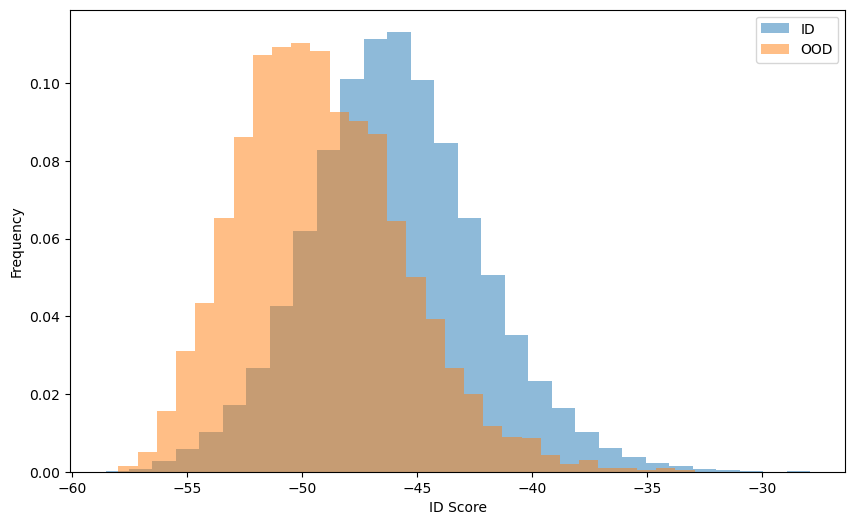

       TNR    AUROC  DTACC  AUIN   AUOUT 
Bas    23.186 73.893 68.042 97.443 15.971
scikit roc_auc_score:  0.7389298455647076
CPU times: user 15.6 s, sys: 5.35 s, total: 21 s
Wall time: 5.71 s


In [5]:
%%time
score = score_nearest_mean(features['train_beit'], labels['train'], features['test_beit'])

is_id = np.isin(labels['test'], np.unique(labels['train']))
score_id = score[is_id]
score_ood = score[~is_id]

visualise_ood(score_id, score_ood)
metric_ood(score_id.numpy(), score_ood.numpy())
print('scikit roc_auc_score: ', roc_auc_score(is_id, score))

### Features: DinoV2 (generic)

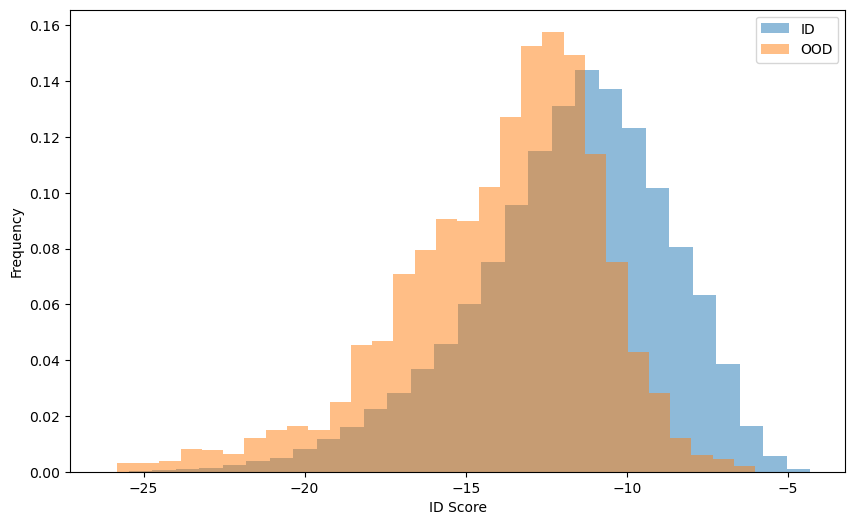

       TNR    AUROC  DTACC  AUIN   AUOUT 
Bas    12.118 69.166 64.417 97.283 11.349
scikit roc_auc_score:  0.6916622938767388
CPU times: user 17.3 s, sys: 5.19 s, total: 22.5 s
Wall time: 5.97 s


In [6]:
%%time
score = score_nearest_mean(features['train_dino'], labels['train'], features['test_dino'])

is_id = np.isin(labels['test'], np.unique(labels['train']))
score_id = score[is_id]
score_ood = score[~is_id]

visualise_ood(score_id, score_ood)
metric_ood(score_id.numpy(), score_ood.numpy())
print('scikit roc_auc_score: ', roc_auc_score(is_id, score))

# Max logits

### BEIT (classification head logits)

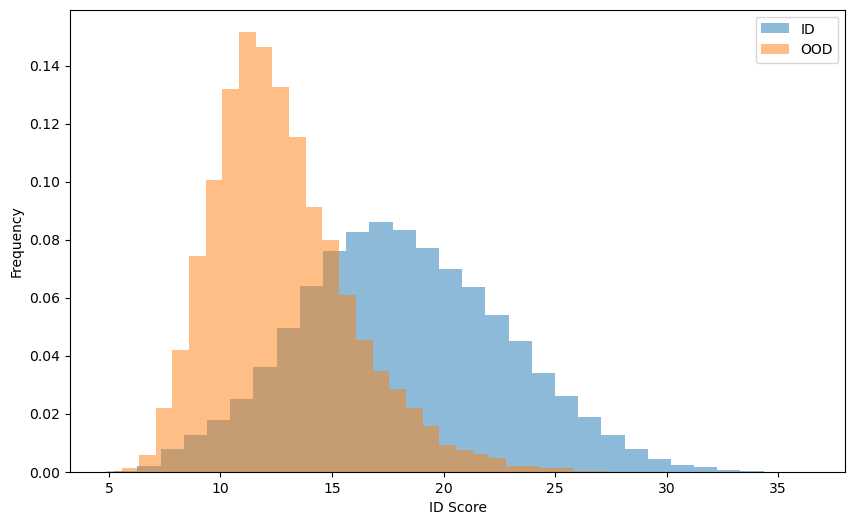

       TNR    AUROC  DTACC  AUIN   AUOUT 
Bas    27.697 83.919 77.184 98.736 20.779
scikit roc_auc_score:  0.8391924256464373
CPU times: user 1.58 s, sys: 10.5 ms, total: 1.59 s
Wall time: 1.23 s


In [8]:
%%time
score, _ = torch.max(logits['test_beit'], dim=1)

is_id = np.isin(labels['test'], np.unique(labels['train']))
score_id = score[is_id]
score_ood = score[~is_id]

visualise_ood(score_id, score_ood)
metric_ood(score_id.numpy(), score_ood.numpy())
print('scikit roc_auc_score: ', roc_auc_score(is_id, score))

### DinoV2 (Linear probe)

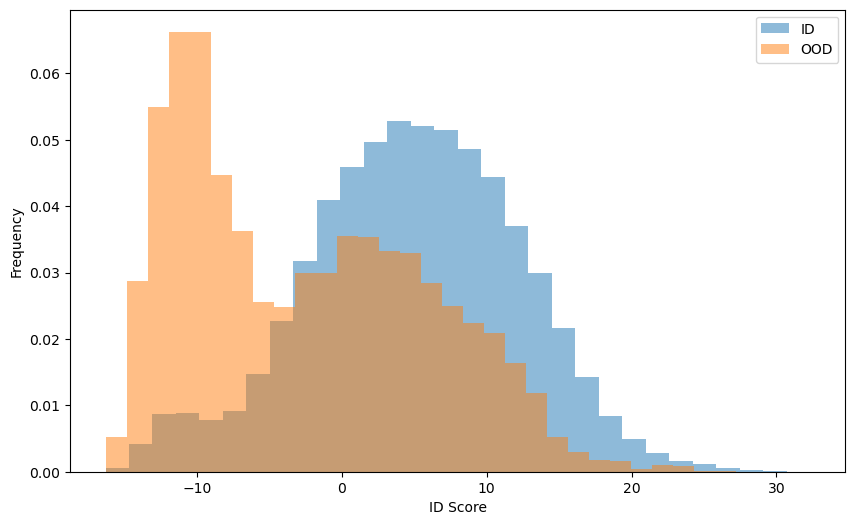

       TNR    AUROC  DTACC  AUIN   AUOUT 
Bas    36.755 74.429 69.365 97.372 20.777
scikit roc_auc_score:  0.7442897314437255
CPU times: user 1.62 s, sys: 1.55 ms, total: 1.62 s
Wall time: 1.24 s


In [9]:
%%time
score, _ = torch.max(logits['test_dino'], dim=1)

is_id = np.isin(labels['test'], np.unique(labels['train']))
score_id = score[is_id]
score_ood = score[~is_id]

visualise_ood(score_id, score_ood)
metric_ood(score_id.numpy(), score_ood.numpy())
print('scikit roc_auc_score: ', roc_auc_score(is_id, score))

# Maximum Softmax probability

### BEIT

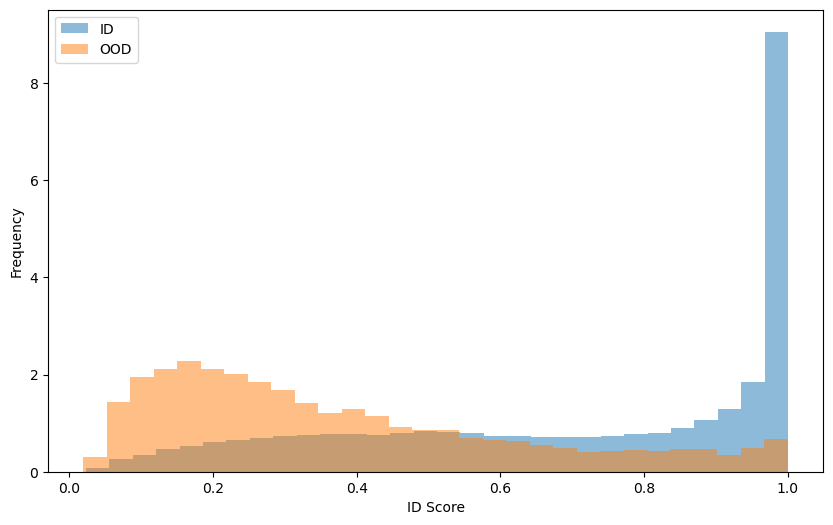

       TNR    AUROC  DTACC  AUIN   AUOUT 
Bas    25.302 79.826 72.346 98.377 18.418
scikit roc_auc_score:  0.7982648570145676
CPU times: user 2 s, sys: 267 ms, total: 2.27 s
Wall time: 1.3 s


In [49]:
%%time
score, _ = torch.max(torch.softmax(logits['test_beit'], dim=1), dim=1)

is_id = np.isin(labels['test'], np.unique(labels['train']))
score_id = score[is_id]
score_ood = score[~is_id]

visualise_ood(score_id, score_ood)
metric_ood(score_id.numpy(), score_ood.numpy())
print('scikit roc_auc_score: ', roc_auc_score(is_id, score))

### DinoV2

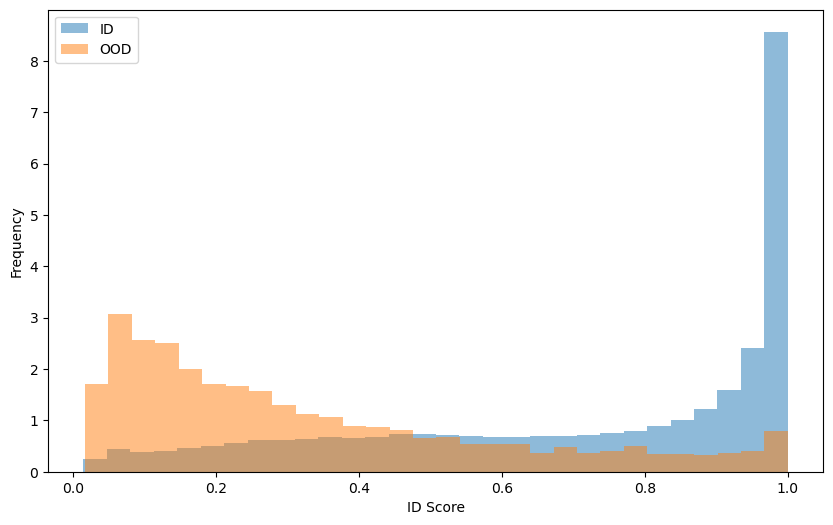

       TNR    AUROC  DTACC  AUIN   AUOUT 
Bas    32.506 82.373 75.006 98.496 21.761
scikit roc_auc_score:  0.8237303868223691
CPU times: user 2.08 s, sys: 67.6 ms, total: 2.15 s
Wall time: 1.39 s


In [58]:
%%time
score, _ = torch.max(torch.softmax(logits['test_dino'], dim=1), dim=1)

is_id = np.isin(labels['test'], np.unique(labels['train']))
score_id = score[is_id]
score_ood = score[~is_id]

visualise_ood(score_id, score_ood)
metric_ood(score_id.numpy(), score_ood.numpy())
print('scikit roc_auc_score: ', roc_auc_score(is_id, score))